<a href="https://colab.research.google.com/github/devigorll/cursocienciadedados/blob/main/11_geracao_graficos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11. Este arquivo visa estudar e entender como funciona a geração de gráficos por meio das bibliotecas Matplotlib e Seaborn

---



In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Gerando gráficos com Matplotlib

---



In [ ]:
base = pd.read_csv("/content/drive/MyDrive/UDEMY/CURSO CD/05. GRAFICOS VISUALIZACOES E DASHBOARDS/Cópia de trees.csv", delimiter = ",")
base

In [ ]:
base.head()
base.columns = ["CIRCUNFERENCIA", "ALTURA", "VOLUME"]

Histogramas

Text(0, 0.5, 'Frequência')

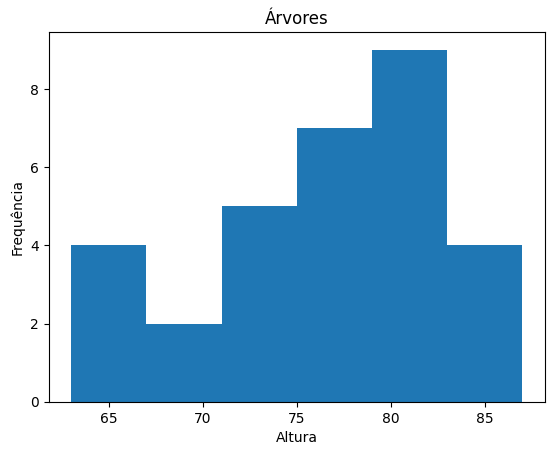

In [ ]:
# Gerando histograma com matplolib

plt.hist(base.iloc[:,1], bins = 6)
plt.title("Árvores")
plt.xlabel("Altura")
plt.ylabel("Frequência")

Gráfico de Dispersão

Text(0, 0.5, 'Volume')

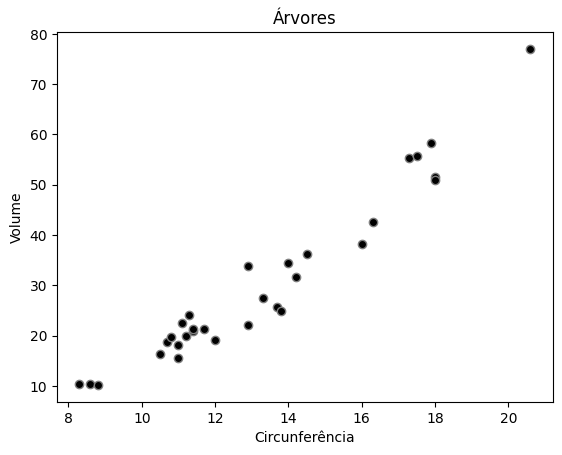

In [ ]:
# Gerando gráfico de dispersão a partir da biblioteca Matplolib
plt.scatter(x = base.CIRCUNFERENCIA, y = base.VOLUME, color = "gray", facecolors = "black", marker = "o" )
plt.title("Árvores")
plt.xlabel("Circunferência")
plt.ylabel("Volume")

In [ ]:
dataframe = pd.read_csv("/content/drive/MyDrive/UDEMY/CURSO CD/05. GRAFICOS VISUALIZACOES E DASHBOARDS/Cópia de co2.csv", delimiter = ",")

dataframe

In [ ]:
x = dataframe.conc
y = dataframe.uptake

In [ ]:
unicos = list(set(dataframe.Treatment))
unicos

['nonchilled', 'chilled']

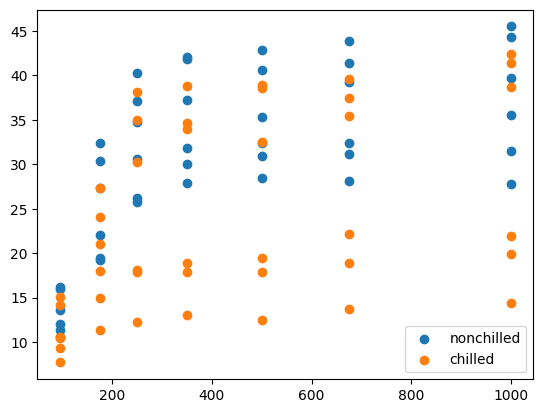

In [ ]:
for i in range(len(unicos)):
  indice = dataframe.Treatment == unicos[i]
  plt.scatter(x[indice], y[indice], label = unicos[i])
plt.legend(loc = "lower right")

In [ ]:
dataframe.shape

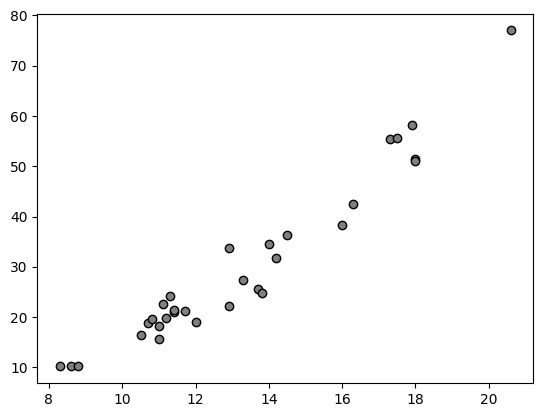

In [ ]:
plt.scatter(base.CIRCUNFERENCIA, base.VOLUME, marker = "o", color = "black", facecolors = "gray")

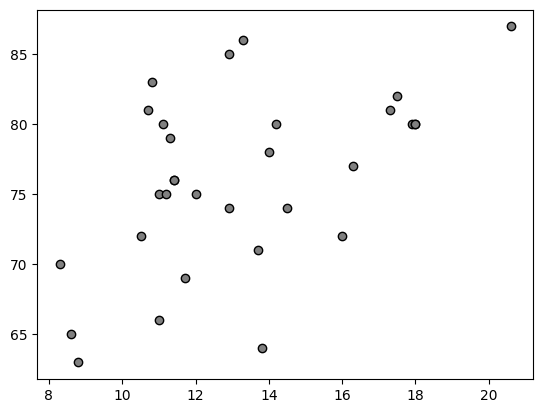

In [ ]:
plt.scatter(base.CIRCUNFERENCIA, base.ALTURA, marker = "o", color = "black", facecolors = "gray")

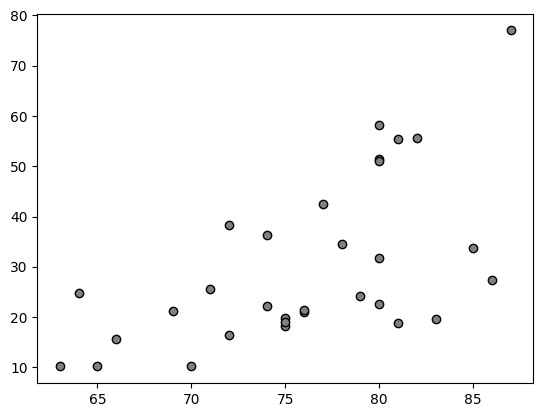

In [ ]:
plt.scatter(base.ALTURA, base.VOLUME, marker = "o", color = "black", facecolors = "gray")

Dividindo janela para iterar gráficos

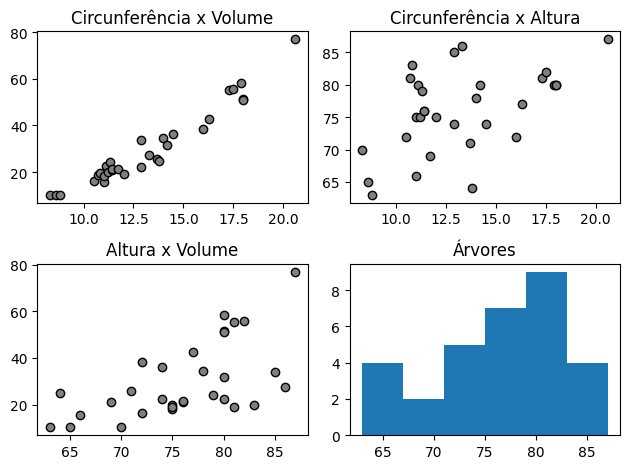

In [ ]:
plt.figure(1)
plt.subplot(2,2,1)
plt.scatter(base.CIRCUNFERENCIA, base.VOLUME, marker = "o", color = "black", facecolors = "gray")
plt.title("Circunferência x Volume")
plt.subplot(2,2,2)
plt.scatter(base.CIRCUNFERENCIA, base.ALTURA, marker = "o", color = "black", facecolors = "gray")
plt.title("Circunferência x Altura")
plt.subplot(2,2,3)
plt.scatter(base.ALTURA, base.VOLUME, marker = "o", color = "black", facecolors = "gray")
plt.title("Altura x Volume")
plt.subplot(2,2,4)
plt.hist(base.iloc[:,1], bins = 6)
plt.title("Árvores")
plt.tight_layout()

Boxplot

Text(0.5, 0, 'Volume')

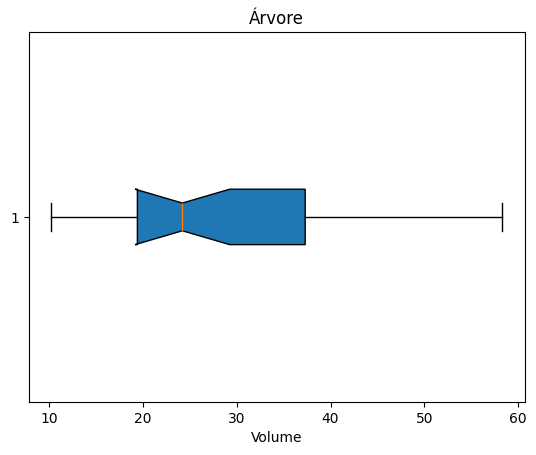

In [ ]:
plt.boxplot(base.VOLUME, vert = False, showfliers = False, notch = True, patch_artist = True)
plt.title("Árvore")
plt.xlabel("Volume")

In [ ]:
base

Gráficos de barras e setores

In [ ]:
base_insect = pd.read_csv("/content/drive/MyDrive/UDEMY/CURSO CD/05. GRAFICOS VISUALIZACOES E DASHBOARDS/Cópia de insect.csv", delimiter = ",")
base_insect

In [ ]:
base_insect.shape

(72, 2)

In [ ]:
agrupado = base_insect.groupby(["spray"])["count"].sum()
agrupado

,count
spray,
A,174
B,184
C,25
D,59
E,42
F,200


<Axes: xlabel='spray'>

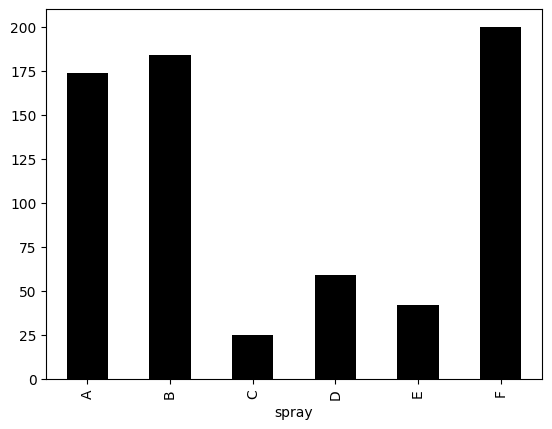

In [ ]:
agrupado.plot.bar(color = "black")

<Axes: xlabel='spray'>

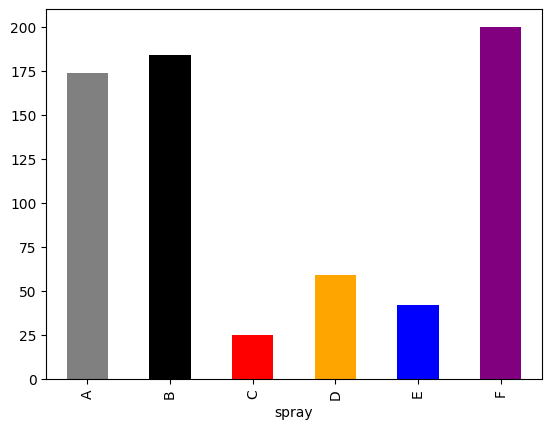

In [ ]:
# setando as cores de cada coluna
agrupado.plot.bar(color = ["gray", "black", "red", "orange", "blue", "purple"])

Gráfico de Setor

<Axes: ylabel='count'>

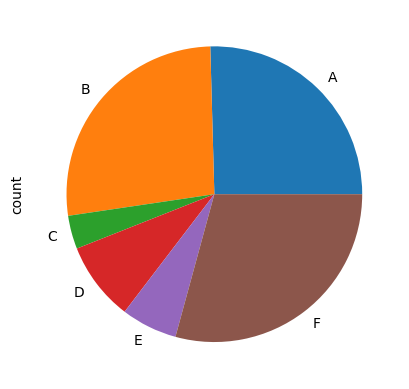

In [ ]:
# Gerando gráfico por setor
agrupado.plot.pie()

<Axes: ylabel='count'>

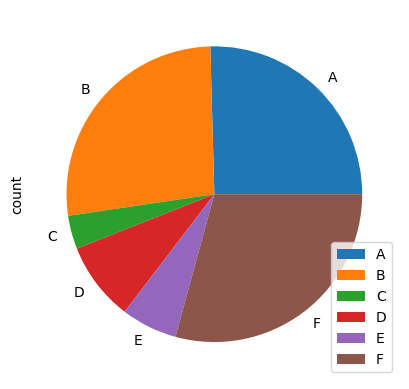

In [ ]:
# Adicionando legenda
agrupado.plot.pie(legend = True)

Gerando gráficos com Seaborn


---






Histograma com linha de densidade

In [ ]:
base2 = pd.read_csv("/content/drive/MyDrive/UDEMY/CURSO CD/05. GRAFICOS VISUALIZACOES E DASHBOARDS/Cópia de chicken.csv", delimiter = ",")
base2.columns = ["PESO", "ALIMENTO"]
base2.shape

(71, 2)

In [ ]:
agrupado = base2.groupby(["ALIMENTO"])["PESO"].sum()
agrupado

,PESO
ALIMENTO,
casein,3883
horsebean,1602
linseed,2625
meatmeal,3046
soybean,3450
sunflower,3947


In [ ]:
teste = base2.loc[base2.ALIMENTO == "horsebean"]
teste

,PESO,ALIMENTO
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean
5,168,horsebean
6,108,horsebean
7,124,horsebean
8,143,horsebean
9,140,horsebean


Text(0.5, 1.0, 'Horsebean')

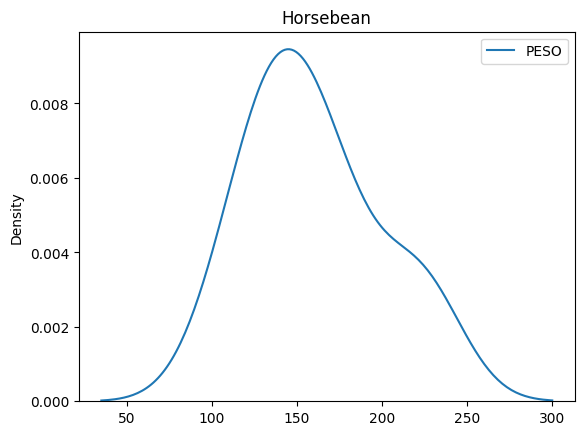

In [ ]:
# Gerando gráfico com linha de densidade
sns.kdeplot(base2.loc[base2.ALIMENTO == "horsebean"]).set_title("Horsebean")

[Text(0.5, 1.0, 'Casein')]

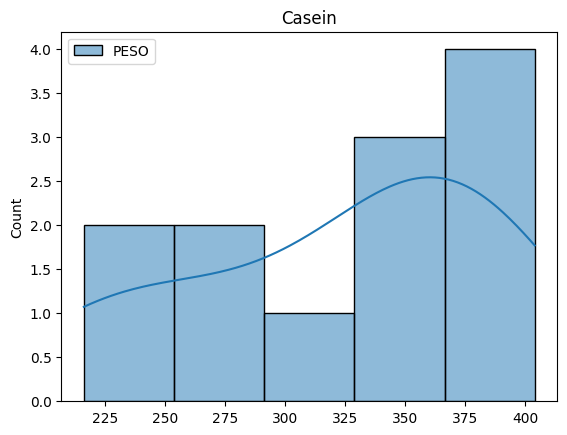

In [ ]:
sns.histplot(base2.loc[base2["ALIMENTO"] == "casein"], kde = True).set(title = "Casein")

Text(0.5, 1.0, 'Linseed')

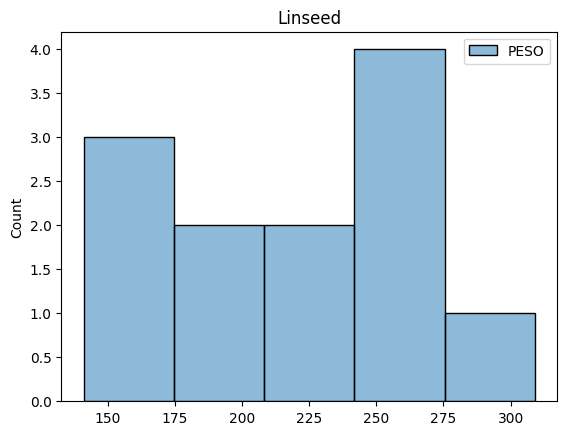

In [ ]:
sns.histplot(base2.loc[base2.ALIMENTO == "linseed"], kde = False, color = "gray").set_title("Linseed")

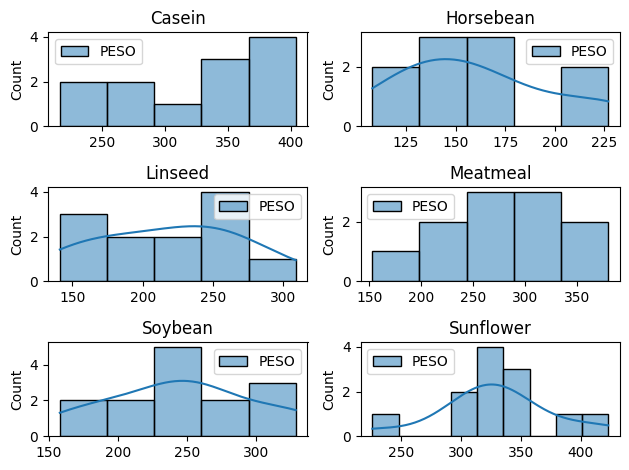

In [ ]:
plt.figure()
plt.subplot(3, 2, 1)
sns.histplot(base2.loc[base2.ALIMENTO == "casein"], kde = False).set_title("Casein")
plt.subplot(3, 2, 2)
sns.histplot(base2.loc[base2.ALIMENTO == "horsebean"], kde = True).set_title("Horsebean")
plt.subplot(3, 2, 3)
sns.histplot(base2.loc[base2.ALIMENTO == "linseed"], kde = True).set(title = "Linseed")
plt.subplot(3, 2, 4)
sns.histplot(base2.loc[base2["ALIMENTO"] == "meatmeal"], kde = False).set(title = "Meatmeal")
plt.subplot(3, 2, 5)
sns.histplot(base2.loc[base2.ALIMENTO == "soybean"], kde = True).set_title("Soybean")
plt.subplot(3, 2, 6)
sns.histplot(base2.loc[base2.ALIMENTO == "sunflower"], kde = True).set_title("Sunflower")

# Ajusta a figura para que os gráficos não se sobreponham
plt.tight_layout()

In [ ]:
teste2 = base2.groupby(["ALIMENTO"])["PESO"].count()
teste2

,PESO
ALIMENTO,
casein,12
horsebean,10
linseed,12
meatmeal,11
soybean,14
sunflower,12


[Text(0.5, 1.0, 'Árvores')]

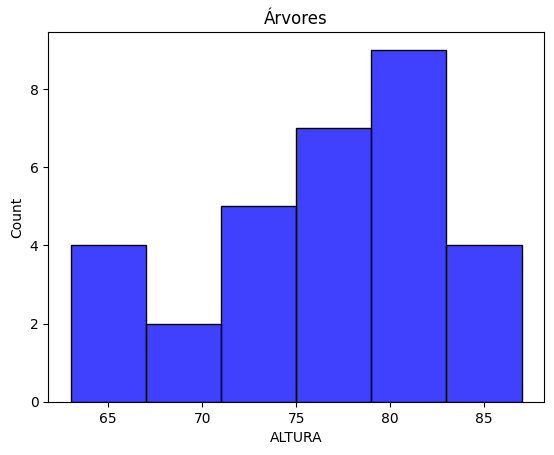

In [ ]:
# Gerando histograma com a biblioteca seaborn
# KDE = Linha de densidade | Como está False, não aparece

sns.histplot(base.iloc[:,1], kde = False, color = "blue").set(title = "Árvores")

[Text(0.5, 1.0, 'Árvore')]

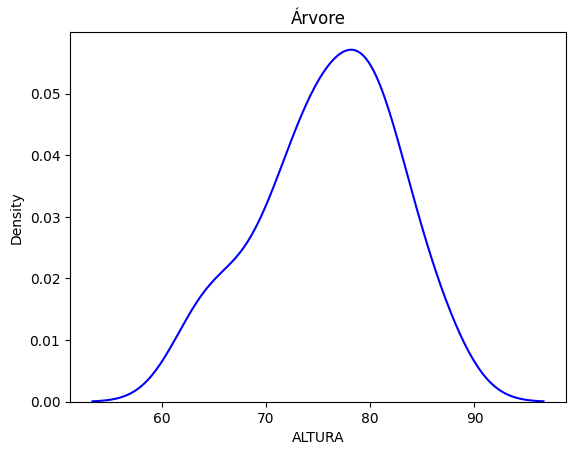

In [ ]:
# Gerando gráfico de linha de densidade

sns.kdeplot(base.iloc[:,1], color = "blue").set(title="Árvore")

Gráfico de Dispersão

[Text(0.5, 1.0, 'Árvores')]

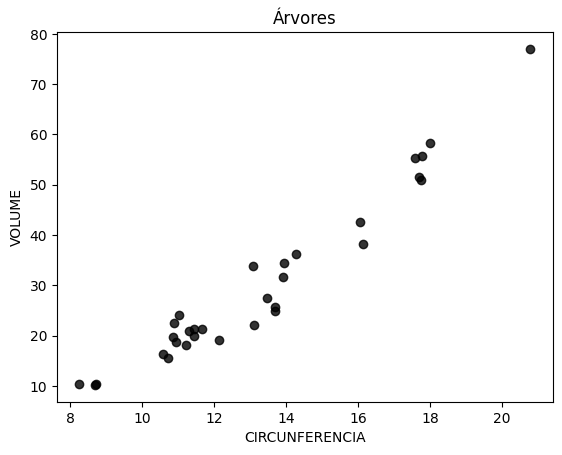

In [ ]:
# Gerando gráfico de dispersão a partir da biblioteca Seabron
# x_jitter = indica o espaço que o ponto pode variar para não haver sobreposição
# fir_reg = Linha de tendência
sns.regplot(x = base.CIRCUNFERENCIA, y = base.VOLUME, data = base, color = "black", x_jitter = 0.3, fit_reg = False).set(title = "Árvores")

Boxplot

Text(0.5, 1.0, 'Árvore')

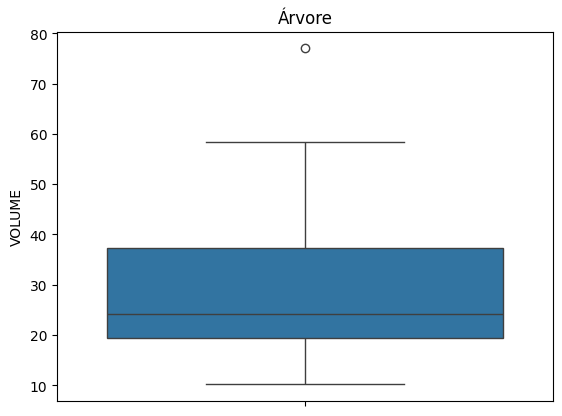

In [ ]:
# Gerando Boxplot com Seaborn]

sns.boxplot(data = base.VOLUME, orient = "v").set_title("Árvore")

<Axes: >

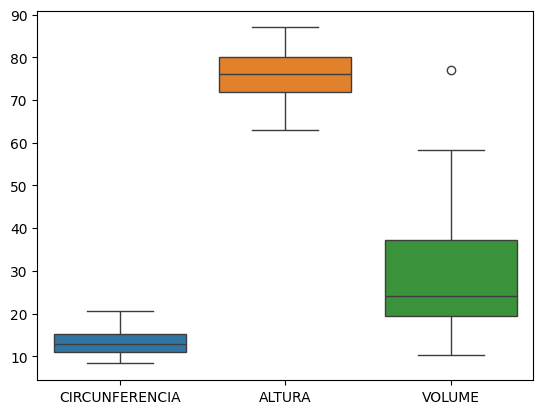

In [ ]:
sns.boxplot(data = base)

Gráfico de dispersão

In [6]:
base3 = pd.read_csv("/content/drive/MyDrive/UDEMY/CURSO CD/05. GRAFICOS VISUALIZACOES E DASHBOARDS/Cópia de co2.csv")

base3

,Plant,Type,Treatment,conc,uptake
0,Qn1,Quebec,nonchilled,95,16.0
1,Qn1,Quebec,nonchilled,175,30.4
2,Qn1,Quebec,nonchilled,250,34.8
3,Qn1,Quebec,nonchilled,350,37.2
4,Qn1,Quebec,nonchilled,500,35.3
...,...,...,...,...,...
79,Mc3,Mississippi,chilled,250,17.9
80,Mc3,Mississippi,chilled,350,17.9
81,Mc3,Mississippi,chilled,500,17.9
82,Mc3,Mississippi,chilled,675,18.9


<Axes: xlabel='conc', ylabel='uptake'>

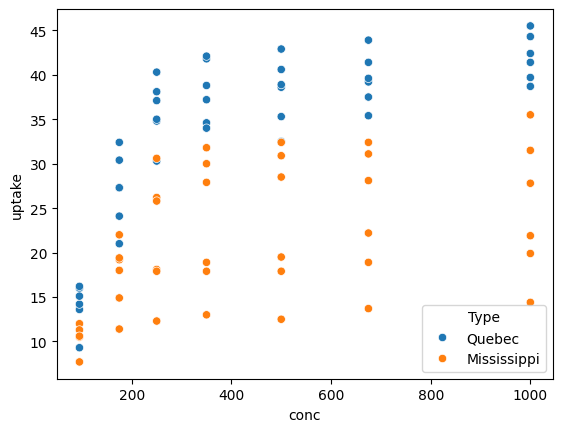

In [9]:
# Gerando gráfico de dispersão com duas variáveis agrupando pelo tipo

sns.scatterplot(x = base3.conc,  y = base3.uptake, hue = base3.Type)

In [11]:
q = base3.loc[base3.Type == "Quebec"]
m = base3.loc[base3.Type == "Mississippi"]

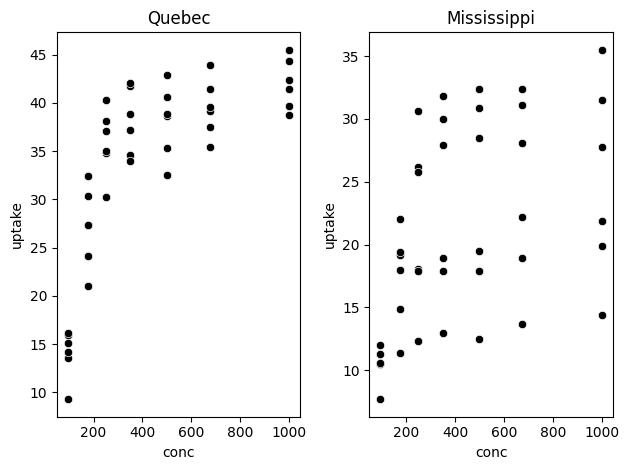

In [14]:
plt.figure()
plt.subplot(1, 2, 1)
sns.scatterplot(x = q.conc, y = q.uptake, color = "gray", facecolors = "black").set_title("Quebec")
plt.subplot(1, 2, 2)
sns.scatterplot(x = m.conc, y = m.uptake, color = "gray", facecolors = "black").set_title("Mississippi")
plt.tight_layout()

In [15]:
ch = base3.loc[base3.Treatment == "chilled"]
nc = base3.loc[base3.Treatment == "nonchilled"]

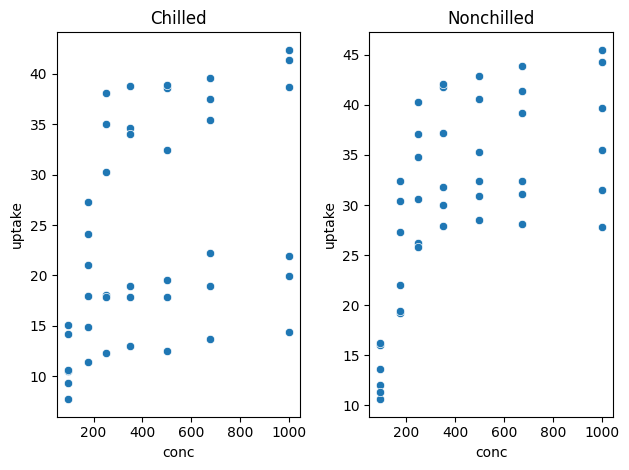

In [17]:
plt.figure()
plt.subplot(1, 2, 1)
sns.scatterplot(x = ch.conc, y = ch.uptake).set_title("Chilled")
plt.subplot(1, 2, 2)
sns.scatterplot(x = nc.conc, y = nc.uptake).set_title("Nonchilled")
plt.tight_layout()


In [18]:
esoph = pd.read_csv("/content/drive/MyDrive/UDEMY/CURSO CD/05. GRAFICOS VISUALIZACOES E DASHBOARDS/Cópia de esoph.csv")
esoph

,agegp,alcgp,tobgp,ncases,ncontrols
0,25-34,0-39g/day,0-9g/day,0,40
1,25-34,0-39g/day,10-19,0,10
2,25-34,0-39g/day,20-29,0,6
3,25-34,0-39g/day,30+,0,5
4,25-34,40-79,0-9g/day,0,27
...,...,...,...,...,...
83,75+,40-79,30+,1,1
84,75+,80-119,0-9g/day,1,1
85,75+,80-119,10-19,1,1
86,75+,120+,0-9g/day,2,2


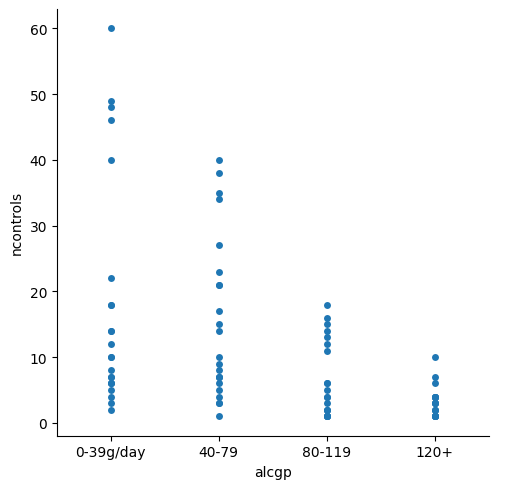

In [23]:
sns.catplot(x = "alcgp", y = "ncontrols", data = esoph, jitter = False)

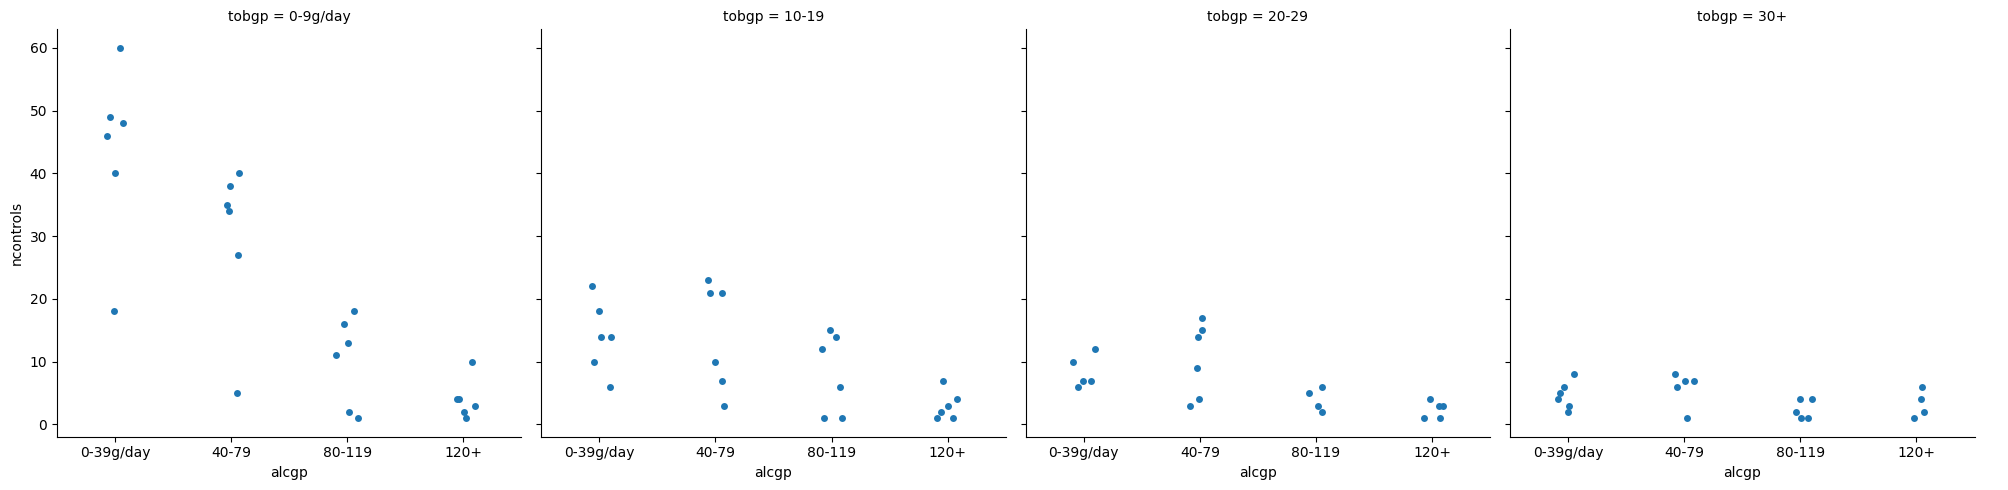

In [27]:
# dividindo por categoria
sns.catplot(x = "alcgp", y = "ncontrols", data = esoph, col = "tobgp")